In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/train.csv")
df.tail(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
41990,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41991,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41992,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41993,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41994,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41999,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape


(42000, 785)

In [4]:
df.iloc[0]

label       1
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 0, Length: 785, dtype: int64

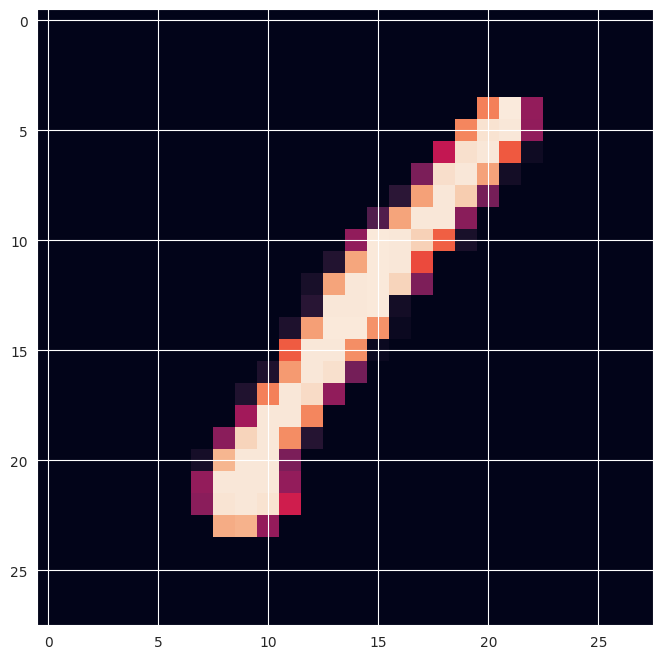

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.imshow(df.iloc[0, 1:].values.reshape(28, 28))
plt.show()

In [6]:
 df.iloc[250].describe().T

count    785.000000
mean      38.917197
std       86.421411
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      255.000000
Name: 250, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split


In [8]:
X = df.drop(columns=["label"]) / 255
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [9]:
X.iloc[250].describe()

count    784.000000
mean       0.152791
std        0.339088
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: 250, dtype: float64

In [10]:
from sklearn.svm import LinearSVC

In [11]:
model = LinearSVC(
    penalty="l2",
    dual=False,
    tol=1e-5
)
model.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,False
,tol,1e-05
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [12]:
from sklearn.metrics import accuracy_score

In [13]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9078571428571428

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [15]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.952     0.975     0.964       408
           1      0.946     0.975     0.960       471
           2      0.881     0.883     0.882       420
           3      0.902     0.854     0.877       506
           4      0.912     0.935     0.923       397
           5      0.850     0.870     0.860       339
           6      0.940     0.938     0.939       402
           7      0.924     0.911     0.917       438
           8      0.869     0.854     0.861       403
           9      0.886     0.882     0.884       416

    accuracy                          0.908      4200
   macro avg      0.906     0.908     0.907      4200
weighted avg      0.908     0.908     0.908      4200



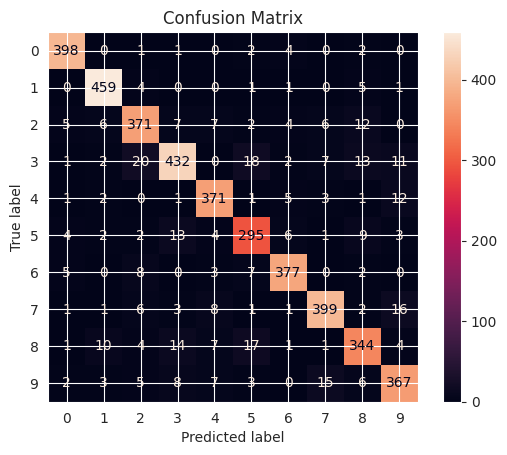

In [16]:
cm = confusion_matrix(y_test, y_pred, labels= np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

fig, ax = plt.subplots()
disp.plot(values_format="d", cmap=None, ax=ax)
ax.set_title("Confusion Matrix")

plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [18]:
penalties = ["l1", "l2"]
tolerances = [1e-3, 1e-4, 1e-5]

param_grid = {
    "penalty": penalties,
    "tol": tolerances,
}



In [19]:
grid_search = GridSearchCV(
    LinearSVC(dual=False),
    param_grid,
    cv=3 #cross validation
)
grid_search.fit(X_train, y_train)

/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:125

,estimator,LinearSVC(dual=False)
,param_grid,"{'penalty': ['l1', 'l2'], 'tol': [0.001, 0.0001, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [20]:
random_search = RandomizedSearchCV(
    estimator=LinearSVC(dual=False),
    param_distributions=param_grid,
    n_iter=4,
    cv=3,
    random_state=42
)

In [21]:
random_search.fit(X_train, y_train)

/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/marcin/workspace/data_sience/preparing_data_for_ml/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:125

,estimator,LinearSVC(dual=False)
,param_distributions,"{'penalty': ['l1', 'l2'], 'tol': [0.001, 0.0001, ...]}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
print(grid_search.best_params_, grid_search.best_score_)
print(random_search.best_params_, random_search.best_score_)

{'penalty': 'l1', 'tol': 0.001} 0.9091005291005292
{'tol': 0.001, 'penalty': 'l1'} 0.9091269841269841
